<a href="https://colab.research.google.com/github/vgorbikov/ml-phys-vsu-gorbikov/blob/main/02-classification/02_Gorbikov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 2. Бинарная классификация.
В этом задании вам предстоит пройти путь от анализа и обработки данных до построения модели машинного обучения для решения задачи бинарной классификации.

**Датасет**: космический корабль «Титаник» с почти 13 000 пассажирами на борту отправился в свой первый рейс, чтобы доставить эмигрантов из нашей Солнечной системы к трем новым обитаемым экзопланетам, вращающимся вокруг ближайших звезд. К сожалению, по пути судно натолкнулось на пространственно-временную аномалию, вследствие чего почти половина пассажиров была перенесена в другое измерение! Чтобы помочь спасателям, необходимо на основе имеющихся сведений научиться предсказывать, кто из пассажиров был перенесен, а кто остался на корабле. [Ссылка](https://www.kaggle.com/competitions/spaceship-titanic) на страницу соревнования на Kaggle.

**Описание признаков:**

- `PassengerId`: уникальный ID для каждого пассажира. Каждый идентификатор имеет формат gggg_pp, где gggg указывает группу, с которой путешествует пассажир, а pp — его номер в группе. Люди в группе часто являются членами семьи, но не всегда.
- `HomePlanet`: планета, с которой пассажир отправился в путешествие
- `CryoSleep`: указывает, был ли пассажир быть переведен в режим анабиоза на время рейса.
- `Cabin`: номер кабины.
- `Destination`: планета назначения.
- `Age`: возраст.
- `VIP`: оплатил ли пассажир специальное VIP-обслуживание во время рейса.
- `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`: сумма, которую пассажир заплатил за различные удобства на борту.
- `Name`: Имя и фамилия.
- `Transported`: был ли пассажир перенесен в другое измерение. Это целевая переменная, которую необходимо предсказать.

- Импортируйте необходимые библиотеки. Загрузите датасет и отобразите первые несколько объектов, установите колонку `PassengerId` в качестве индекса. Разбейте для удобства исходный датафрейм на матрицу объектов-признаков $X$ и целевую переменную $y$

In [17]:
#Смонтируем диск с данными (только для Google Drive)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
dataset_file_path = "/content/drive/My Drive/education/ml_vsu/02-classification/train.csv"

Mounted at /content/drive


In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = pd.read_csv(dataset_file_path, index_col='PassengerId')
data.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
PassengerId,,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [19]:
# Разбиваем исходные данные на признаки и целевую переменную
x_data = data.loc[:, 'HomePlanet':'Name']
y_data = data.loc[:, 'Transported']

- Для задания нам не понадобятся признаки `Cabin` и `Name`, отбросьте их. Отобразите, сколько признаков у нас осталось и сколько всего объектов в датасете.

In [20]:
x_data.drop(columns=['Cabin', 'Name'], inplace=True)
params_count = len(x_data.columns)
objs_count = len(x_data.index)

print(f'[info] Имеем {objs_count} объект/ов и {params_count} признак/ов')

[info] Имеем 8693 объект/ов и 10 признак/ов


### Визуализация данных

Можете пользоваться как matplotlib, так и Seaborn

- Нарисуйте столбчатую диаграмму для признака `HomePlanet`. С какой планеты отправилось больше всего пассажиров?

<Axes: xlabel='HomePlanet', ylabel='Number of passengers'>

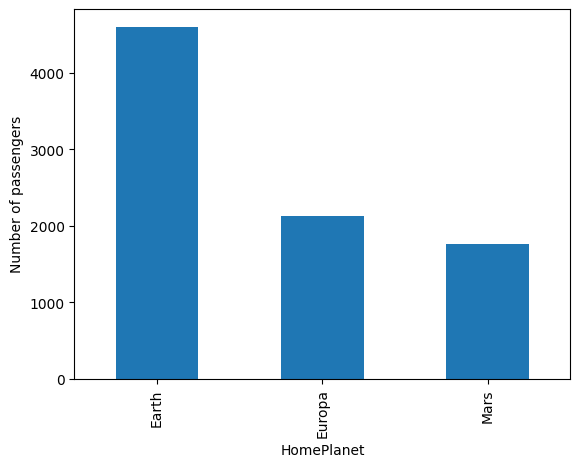

In [21]:
x_data.HomePlanet.value_counts().plot.bar(ylabel='Number of passengers')

> Очевидно, большинство пассажиров летело с Земли :)

- Отобразите распределение таргета целевой переменной. Что можно о нем сказать? Оправдано ли использование метрики Accuracy в данной задаче?

<Axes: xlabel='Transported'>

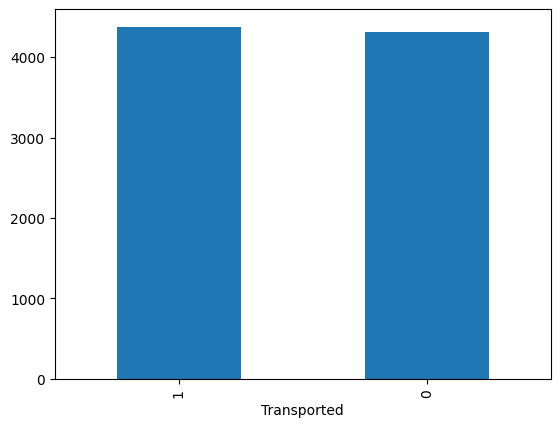

In [22]:
# Т.к имеем целевую переменную с небольши кол-вом дискретных значений, я решил что лучшм вариантом будет отображение распределения в виде столбчатой диаграммы
y_data.map(lambda x: 1 if x else 0).value_counts().plot.bar()

> Да, так-как целевая переменная распределена равномерно, мы можем использовать метрику Accuracy

- Постройте распределения признаков `Age`, `RoomService` и `ShoppingMall` и найдите для каждого из них среднее, медиану, среднеквадратическое отклонение и 0.9-квантиль.

Avg: 28.82793046746535; Median: 27.0; Quantile 0.9: 49.0.


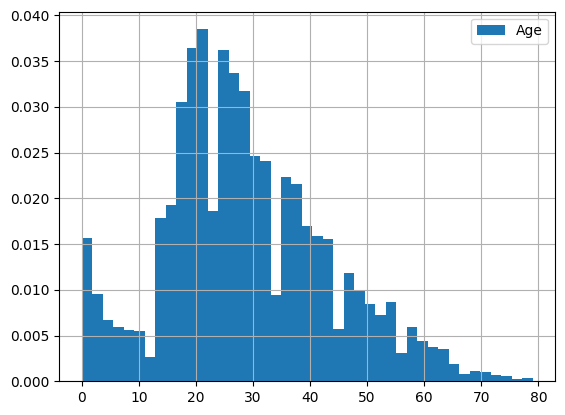

In [23]:
x_data.Age.hist(density=True, bins='auto', legend='Age')

age_avg = x_data.Age.mean()
age_median = x_data.Age.median()
age_quantile = x_data.Age.quantile(0.9)

print(f'Avg: {age_avg}; Median: {age_median}; Quantile 0.9: {age_quantile}.')

Avg: 224.687617481203; Median: 0.0; Quantile 0.9: 753.0.


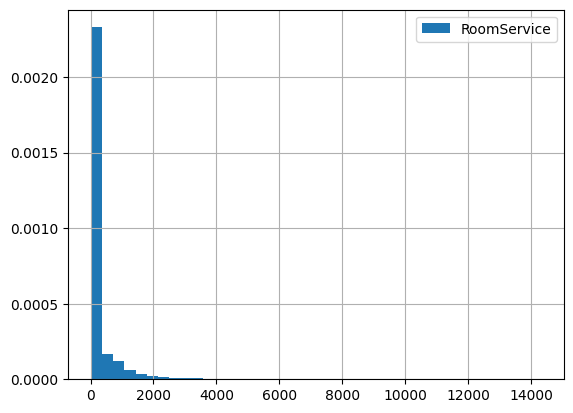

In [24]:
x_data.RoomService.hist(density=True, bins=40, legend='Room Service')

rservice_avg = x_data.RoomService.mean()
rservice_median = x_data.RoomService.median()
rservice_quantile = x_data.RoomService.quantile(0.9)

print(f'Avg: {rservice_avg}; Median: {rservice_median}; Quantile 0.9: {rservice_quantile}.')

Avg: 173.72916912197996; Median: 0.0; Quantile 0.9: 619.6000000000004.


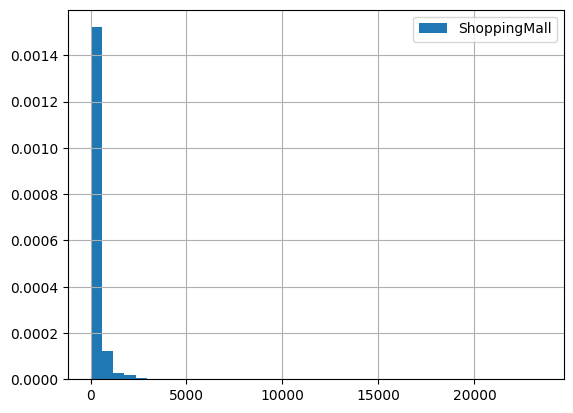

In [25]:
x_data.ShoppingMall.hist(density=True, bins=40, legend='Shopping Mall')

shmall_avg = x_data.ShoppingMall.mean()
shmall_median = x_data.ShoppingMall.median()
shmall_quantile = x_data.ShoppingMall.quantile(0.9)

print(f'Avg: {shmall_avg}; Median: {shmall_median}; Quantile 0.9: {shmall_quantile}.')

### Подготовка данных

- Для проверки работы модели будем использовать **валидацию на отложенной выборке**: часть данных будет использоваться для тренировки алгоритма, другая (меньшая) часть для валидации.

  Воспользуйтесь функцией `train_test_split` из библиотеки scikit-learn для разделения исходных $X$ и $Y$ на тренировочные и валидационные данные. Размер валидационной выборки установите равным 20 процентам от общего размера выборки.

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2)

- Некоторые функции преобразования зависят от состава выборки. Как мы увидим далее, кодирование категориальных данных может зависеть от частоты появления той или иной категории в датасете, параметры StandartScaler также зависят от тренировочной выборки и т.д. Правильным подходом является "настройка" всех функций преобразований на тренировочном датасете, а затем применение их на валидационном датасете (подобно тому, как мы обучаем модель на трейне, а на валидационных данных только проверяем). Если применить все преобразования перед разделением датасета на train и validation, то мы столкнемся с проблемой **утечки данных (data leakage)**. В таком случае оценка нашей модели будет не совсем честной и искаженной (пусть даже если и немного).

  В заданиях ниже необходимо будет преобразовывать как $X_{train}$, так и $X_{val}$
  
  Определите, какие из категориальных признаков в данных являются бинарными (принимают два значения). Преобразуйте их так, чтобы они принимали значения $0$ или $1$. Если в колонке имеются пропуски, замените их наиболее часто встречающимся значением (модой) в тренировочном датасете.

In [27]:
def bin_categorization(dset: pd.DataFrame, col_enc: list[str] = [None], labels: tuple = (True, False)):
  """
  Функция для категоризации бинарных признаков.
  По умолчанию преобразует логические значения
  """
  for col in col_enc:
    if col is None:
      series = dset
    else:
      series = dset[col]

    series = series.map(lambda x: 1 if x==labels[0] else 0, na_action='ignore')
    if not all(series.notna()):
      m_o = series.mode().values[0]
      series = series.map(lambda x: m_o if pd.isna(x) else x)

    dset[col] = series
  return series

In [28]:
# Категоризация бинарных категориальных прихнаков в тестовой и валидационной выборке
bin_categorization(x_train, ['CryoSleep', 'VIP'])
bin_categorization(x_test, ['CryoSleep', 'VIP'])

y_train = bin_categorization(y_train)
y_test = bin_categorization(y_test)

- На лекции мы рассматривали один из самых распространенных и простых методов кодирования категориальных данных - **one-hot кодирование**. Мы использовали его, когда признак мог принимать несколько (больше двух) значений. Одним из минусов этого алгоритма является то, что мы добавляем новые колонки в наш датасет, тем самым расширяя признаковое пространство при неизменном количестве исходных объектов.\
Рассмотрим другой метод кодирования категориальных данных - **Frequency Encoding (частотное кодирование**). В этом подходе каждая категория (рассматриваем некоторый признак) заменяется на число, равное количеству объектов с этим значением категории делённое на количество всех объектов. Иными словами мы пытаемся найти, насколько часто соответствующая категория встречается в наших данных. Пример работы алгоритма:
  
  

> 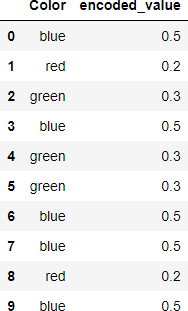

Данный метод достаточно прост и эффективен в использовании, он также не создает множество новых признаков в отличие от one-hot кодировани. Однако есть и минус: если две или несколько категорий встречаются в данных примерно одинаковое количество раз, то и закодированные величины будут очень близки друг к другу. Это может привести к тому, что для модели будет тяжелее выявить отличия между категориями.

**Реализуйте функцию**, которая будет принимать на вход тренировочный и валидационный датафреймы и список колонок для преобразования. Обратите внимание, что **в колонках могут быть пропущенные значения** (NaN), обработайте их так, будто это еще одна дополнительная категория (например, если бы в примере выше помимо цветов была еще категория 'NaN'). Преобразуйте с помощью этой функции колонки, в которых больше двух категорий. Использовать готовые реализации алгоритма нельзя.

In [29]:
def freq_enc(X_train: pd.DataFrame, X_val: pd.DataFrame, col_enc: list[str]):
  """
  Частотное кодирование небинарных категориальных признаков
  """
  for col in col_enc:
    train_col = X_train[col]
    total_cat_size = len(train_col)
    cats_n = {i[0]:i[1]/total_cat_size for i in train_col.value_counts(dropna=False).items()}

    X_train[col] = train_col.map(cats_n)
    X_val[col] = X_val[col].map(cats_n)

In [30]:
# В нашем случае это два столбца - планета проживания и место назначения
freq_enc(x_train, x_test, ['HomePlanet', 'Destination'])

- На данном этапе у вас не должно остаться пропусков в категориальных признаках. Заполните пропуски в оставшихся колонках медианным значением соответствующего признака. Удостоверьтесь, что у вас больше нет пропусков ни в каком признаке.

In [31]:
def nan_to_median(dset: pd.DataFrame, columns: list[str]):
  """
  Замена NaN-значений признака на медианные по выборке
  """
  for col in columns:
    ser = dset[col]
    m_o = ser.median()
    dset[col] = ser.map(lambda x: m_o if pd.isna(x) else x)

In [32]:
nan_to_median(x_train, ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'])
nan_to_median(x_test, ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'])

In [33]:
print(f'Dataset has no NaN values in columns: \n{x_train.isna().sum() + x_test.isna().sum() == 0}')

Dataset has no NaN values in columns: 
HomePlanet      True
CryoSleep       True
Destination     True
Age             True
VIP             True
RoomService     True
FoodCourt       True
ShoppingMall    True
Spa             True
VRDeck          True
dtype: bool


- Воспользуйтесь функцией `StandardScaler`, чтобы отмасштабировать данные по формуле $z = (x - \mu)/\sigma$, где $\mu$ - среднее значение тренировочных объектов, $\sigma$ - среднеквадратическое отклонение. Не забывайте, что настройка Scaler'а также производится на тренировочном датасете.

In [39]:
# создаём и настраиваем масштабер
scaler = StandardScaler()
scaler.fit(x_train)

# масштабируем
x_train_sld = scaler.transform(x_train)
x_test_sld = scaler.transform(x_test)

In [40]:
x_train_sld

array([[ 0.92494404, -0.74125923,  0.67589397, ..., -0.22641924,
        -0.26665586, -0.25967892],
       [-0.85512276,  1.34905572, -1.26624381, ..., -0.27807747,
        -0.26665586, -0.25967892],
       [ 0.92494404, -0.74125923,  0.67589397, ..., -0.25808074,
        -0.26404153, -0.22973586],
       ...,
       [ 0.92494404, -0.74125923,  0.67589397, ..., -0.27807747,
        -0.24574123,  0.42387848],
       [-0.85512276,  1.34905572,  0.67589397, ..., -0.27807747,
        -0.26665586, -0.25967892],
       [-1.10993436, -0.74125923, -2.01452602, ...,  0.3268237 ,
        -0.26665586, -0.25967892]])

### Обучение и выбор модели

- Данные подготовлены, теперь пришло время переходить к построению модели. Оцените качество логистической регрессии с $L2$-регуляризацией (sklearn.linear_model.LogisticRegression) и метода опорных векторов с ядром `rbf` (sklearn.svm.SVC). Задайте некоторый диапазон для гиперпараметров и найдите, при каких из них метрика качества (будем использовать **Accuracy**) наибольшая. Какой алгоритм показал наилучшие результаты?
  
  Отобразите лучшее значение метрики и при каких параметрах оно достигается. Добейтесь значения Accuracy не меньше 0.77 хотя бы с одним из алгоритмов.

In [63]:
# Логистическая регрессия

# Коэффициент регуляризации
C_regul = [0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]
stat_r = {}

for regul in C_regul:
    lreg = LogisticRegression(C=regul)
    lreg.fit(x_train_sld, y_train)
    predicts = lreg.predict(x_test_sld)
    acc = accuracy_score(y_test, predicts)
    stat_r[acc] = regul
    print(f'Логистическая регрессия L2; C={regul}. \n\tAccuracy: {acc}')

print('\n'+'='*50)
best_acc = max(stat_r.keys())
best_c = stat_r[best_acc]
print(f'Лучший результат: Accuracy = {best_acc} при С = {best_c}')

Логистическая регрессия L2; C=0.8. 
	Accuracy: 0.7757331799884991
Логистическая регрессия L2; C=0.9. 
	Accuracy: 0.7763082231167338
Логистическая регрессия L2; C=1.0. 
	Accuracy: 0.7763082231167338
Логистическая регрессия L2; C=1.1. 
	Accuracy: 0.7763082231167338
Логистическая регрессия L2; C=1.2. 
	Accuracy: 0.7757331799884991
Логистическая регрессия L2; C=1.3. 
	Accuracy: 0.7757331799884991
Логистическая регрессия L2; C=1.4. 
	Accuracy: 0.7757331799884991

Лучший результат: Accuracy = 0.7763082231167338 при С = 1.1


In [64]:
# Метод опорных векторов
import itertools

# сетка со значенями параметров
grid = {
    'C': [1.0, 1.1, 1.2, 1.3],
    'gamma': [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
    }

stat_v = {}

# Будем перебирать все возможные комбинации параметров, которые задали.
param_comb = list(itertools.product(*grid.values()))
for comb in param_comb:
    # Этот словарь можно удобно передавать в объект SVC
    param_dict = dict(zip(grid.keys(), comb))
    svc = SVC(**param_dict)
    svc.fit(x_train_sld, y_train)
    predicts = svc.predict(x_test_sld)
    acc = accuracy_score(y_test, predicts)
    stat_v[acc] = {"C": param_dict["C"], "gamma": param_dict["gamma"]}
    print(f'Метод опорных векторов; C={param_dict["C"]}, gamma={param_dict["gamma"]}. \n\tAccuracy: {acc}')


print('\n'+'='*50)
best_acc = max(stat_v.keys())
best_pair = stat_v[best_acc]
print(f'Лучший результат: Accuracy = {best_acc} при С = {best_pair["C"]}, gamma = {best_pair["gamma"]}')

Метод опорных векторов; C=1.0, gamma=0.05. 
	Accuracy: 0.7791834387579069
Метод опорных векторов; C=1.0, gamma=0.1. 
	Accuracy: 0.7786083956296722
Метод опорных векторов; C=1.0, gamma=0.2. 
	Accuracy: 0.7826336975273146
Метод опорных векторов; C=1.0, gamma=0.3. 
	Accuracy: 0.7832087406555491
Метод опорных векторов; C=1.0, gamma=0.4. 
	Accuracy: 0.780333525014376
Метод опорных векторов; C=1.0, gamma=0.5. 
	Accuracy: 0.7763082231167338
Метод опорных векторов; C=1.1, gamma=0.05. 
	Accuracy: 0.7797584818861415
Метод опорных векторов; C=1.1, gamma=0.1. 
	Accuracy: 0.7826336975273146
Метод опорных векторов; C=1.1, gamma=0.2. 
	Accuracy: 0.7814836112708453
Метод опорных векторов; C=1.1, gamma=0.3. 
	Accuracy: 0.7832087406555491
Метод опорных векторов; C=1.1, gamma=0.4. 
	Accuracy: 0.7791834387579069
Метод опорных векторов; C=1.1, gamma=0.5. 
	Accuracy: 0.7763082231167338
Метод опорных векторов; C=1.2, gamma=0.05. 
	Accuracy: 0.780333525014376
Метод опорных векторов; C=1.2, gamma=0.1. 
	Accura

Как-то так :)